# InceptionV3 Transfer Learning with Flowers Dataset
This notebook demonstrates how to perform transfer learning using InceptionV3 in Keras with a multi-class Flowers RGB dataset.

In [3]:
!pip install split-folders -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [5]:
# Download and unzip dataset
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!mkdir -p ./flowers_dataset
!tar -xvzf flower_photos.tgz -C ./flowers_dataset

'wget' is not recognized as an internal or external command,
operable program or batch file.
The syntax of the command is incorrect.
tar: Error opening archive: Failed to open 'flower_photos.tgz'


In [9]:
!pip install split-folders


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import urllib.request
import tarfile
import os
import splitfolders

# --- PART 1: DOWNLOAD & EXTRACT ---
url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
filename = "flower_photos.tgz"
# This is the folder name created by the extraction
base_folder = "flower_photos" 

if not os.path.exists(filename):
    print("Downloading dataset... this might take a minute.")
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")

if not os.path.exists(base_folder):
    print("Extracting files...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print(f"Extraction complete! Folder '{base_folder}' is ready.")
else:
    print(f"Folder '{base_folder}' already exists.")

# --- PART 2: SPLIT FOLDERS ---
# We use 'base_folder' directly because that's where the images are.
# No need for the "flowers_dataset/" prefix unless you manually moved it.
output_folder = "flowers_split"

if not os.path.exists(output_folder):
    print(f"Splitting files into '{output_folder}'...")
    splitfolders.ratio(base_folder, output=output_folder, seed=42, ratio=(.7, .2, .1))
    print("Success! Data split into Train, Val, and Test.")
else:
    print(f"Split folder '{output_folder}' already exists.")

Folder 'flower_photos' already exists.
Splitting files into 'flowers_split'...


Copying files: 3670 files [00:06, 532.61 files/s]

Success! Data split into Train, Val, and Test.


In [ ]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 64
# data augmentation part
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=30, zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'flowers_split/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(
    'flowers_split/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(
    'flowers_split/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 2567 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


In [16]:
train_generator.num_classes

5

### Transfer Learning

In [18]:
# Load InceptionV3 and add custom layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [20]:
history = model.fit(train_generator, epochs=2, validation_data=val_generator)

Epoch 1/2
41/41 ━━━━━━━━━━━━━━━━━━━━ 320s 7s/step - accuracy: 0.7117 - loss: 0.8222 - val_accuracy: 0.8386 - val_loss: 0.5056
Epoch 2/2
41/41 ━━━━━━━━━━━━━━━━━━━━ 278s 7s/step - accuracy: 0.8512 - loss: 0.4507 - val_accuracy: 0.8564 - val_loss: 0.4088


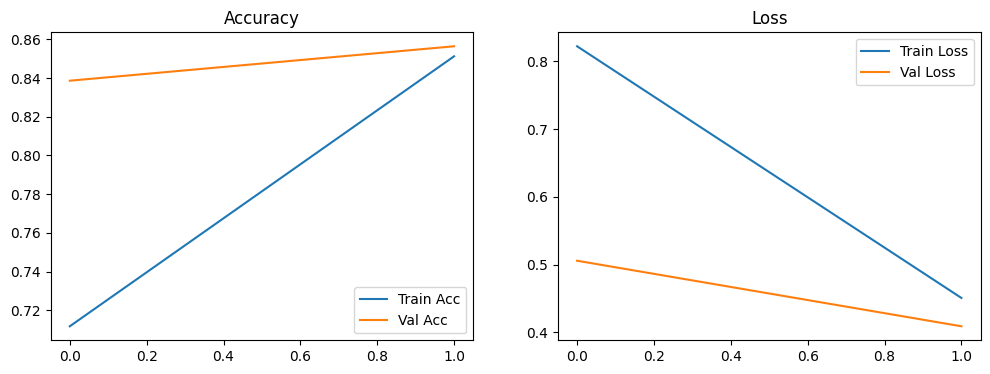

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [22]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8548 - loss: 0.4108
Test Accuracy: 0.8548


In [23]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    class_index = np.argmax(preds)
    class_label = list(train_generator.class_indices.keys())[class_index]
    print(f"Prediction: {class_label} ({preds[0][class_index]*100:.2f}%)")
    # img.show() # This is for PIL Image objects, not needed for matplotlib
    plt.imshow(img) # Use the loaded image for visualization
    plt.axis('off') # Hide axes
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: roses (87.78%)


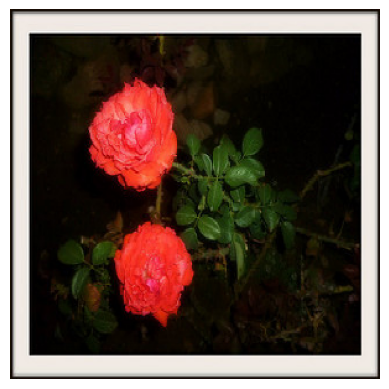

In [25]:
predict_image("flowers_split/test/roses/15104537437_f6730b38c3_n.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Prediction: sunflowers (82.87%)


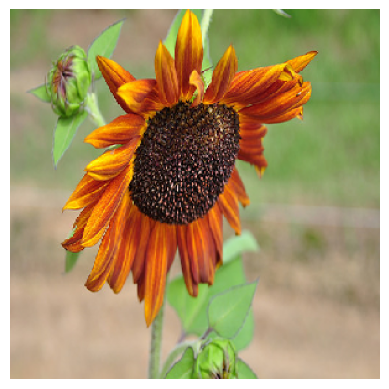

In [26]:
predict_image("flowers_split/test/sunflowers/13117907313_86c99c6441.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Prediction: tulips (97.93%)


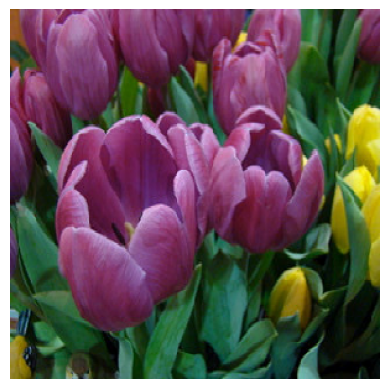

In [28]:
predict_image("flowers_split/test/tulips/12916441224_2ed63596f8_n.jpg")